In [4]:
import yfinance as yf

In [37]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "^GSPC"]
start_date = "2010-01-01"
end_date = "2026-05-01"
df = yf.download(tickers, start=start_date, end=end_date)['Close']

C:\Users\louis\AppData\Local\Temp\ipykernel_13384\374688091.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  6 of 6 completed


In [38]:
#yesterday's values
df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['MSFT(t-1)'] = df['MSFT'].shift(1)
df['GOOGL(t-1)'] = df['GOOGL'].shift(1)
df['AMZN(t-1)'] = df['AMZN'].shift(1)
df['TSLA(t-1)'] = df['TSLA'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)


#"Moving average"
df['AAPL_MA5'] = df['AAPL'].rolling(window=5).mean()
df['MSFT_MA5'] = df['MSFT'].rolling(window=5).mean()
df['GOOGL_MA5'] = df['GOOGL'].rolling(window=5).mean()
df['AMZN_MA5'] = df['AMZN'].rolling(window=5).mean()
df['TSLA_MA5'] = df['TSLA'].rolling(window=5).mean()
df['^GSPC_MA5'] = df['^GSPC'].rolling(window=5).mean()

#set Y Variable  - Next value
df['Target'] = df['AAPL'].shift(-1)
df = df.dropna()
df

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA,^GSPC,AAPL(t-1),MSFT(t-1),GOOGL(t-1),AMZN(t-1),TSLA(t-1),^GSPC(t-1),AAPL_MA5,MSFT_MA5,GOOGL_MA5,AMZN_MA5,TSLA_MA5,^GSPC_MA5,Target
Date,,,,,,,,,,,,,,,,,,,
2010-07-06,7.442847,5.503000,10.823211,17.924585,1.074000,1028.060059,7.392254,17.510706,10.835123,5.457000,1.280000,1022.580017,7.494334,17.543816,10.976944,5.480300,1.399867,1029.992004,7.743397
2010-07-07,7.743397,5.671500,11.173913,18.285784,1.053333,1060.270020,7.442847,17.924585,10.823211,5.503000,1.074000,1028.060059,7.509302,17.692811,10.956790,5.528500,1.292000,1033.798010,7.726035
2010-07-08,7.726035,5.811000,11.331767,18.368567,1.164000,1070.250000,7.743397,18.285784,11.173913,5.671500,1.053333,1060.270020,7.548577,17.903513,11.014421,5.598100,1.207067,1041.706018,7.771838
2010-07-09,7.771838,5.863000,11.603049,18.263210,1.160000,1077.959961,7.726035,18.368567,11.331767,5.811000,1.164000,1070.250000,7.615274,18.070570,11.153413,5.661100,1.146267,1051.824011,7.702085
2010-07-12,7.702085,5.975500,11.810048,18.684612,1.136667,1078.750000,7.771838,18.263210,11.603049,5.863000,1.160000,1077.959961,7.677240,18.305352,11.348398,5.764800,1.117600,1063.058008,7.537740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23,273.178314,255.080002,338.890015,415.750000,373.720001,7108.399902,272.918579,432.920013,339.320007,255.360001,387.510010,7137.899902,270.960364,422.738007,337.920007,251.838000,388.154004,7109.101953,270.810486
2026-04-24,270.810486,263.989990,344.399994,424.619995,376.299988,7165.080078,273.178314,415.750000,338.890015,255.080002,373.720001,7108.399902,271.126208,423.104004,338.464008,254.523999,383.290002,7116.905957,267.363647
2026-04-27,267.363647,261.119995,350.339996,424.820007,378.670013,7173.910156,270.810486,424.619995,344.399994,263.989990,376.299988,7165.080078,270.039209,424.454004,341.048004,257.091998,380.524005,7129.859961,270.460815


## Step 3 lasso regression : 
- import all the required libraries
- define features and target variables
- train test split
- apply lasso regression
- get intercept and coeff for lasso regression
- Predict using lasso regression
- create a dataframe with actual and predicted values
- plot
- evaluate the model (r², mse, rmse)

In [39]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [40]:
X = df.drop(columns=['Target', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', '^GSPC'])
Y = df['Target']

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, shuffle=False) 

In [60]:
Lasso_model = Lasso(alpha=0.4)
Lasso_model.fit(X_train, Y_train) #training the model

c:\Users\louis\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.695e+03, tolerance: 1.376e+03
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.4)

In [61]:
coefficients = Lasso_model.coef_
intercept = Lasso_model.intercept_
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
print(coeff_df)

       Feature  Coefficient
0    AAPL(t-1)     0.873697
1    MSFT(t-1)     0.012970
2   GOOGL(t-1)     0.000000
3    AMZN(t-1)     0.000404
4    TSLA(t-1)     0.000000
5   ^GSPC(t-1)     0.000598
6     AAPL_MA5     0.105248
7     MSFT_MA5     0.000000
8    GOOGL_MA5     0.000000
9     AMZN_MA5     0.000000
10    TSLA_MA5    -0.000000
11   ^GSPC_MA5    -0.000751


In [62]:
y_pred = Lasso_model.predict(X_test)

In [63]:
results_df = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
print(results_df)

                Actual   Predicted
Date                              
2024-09-26  226.095123  225.043084
2024-09-27  231.266373  226.029473
2024-09-30  224.526886  226.345661
2024-10-01  225.092636  230.886273
2024-10-02  223.990875  224.852654
...                ...         ...
2026-04-23  270.810486  271.876250
2026-04-24  267.363647  271.874315
2026-04-27  270.460815  269.833963
2026-04-28  269.921326  266.913425
2026-04-29  271.100250  269.592497

[398 rows x 2 columns]


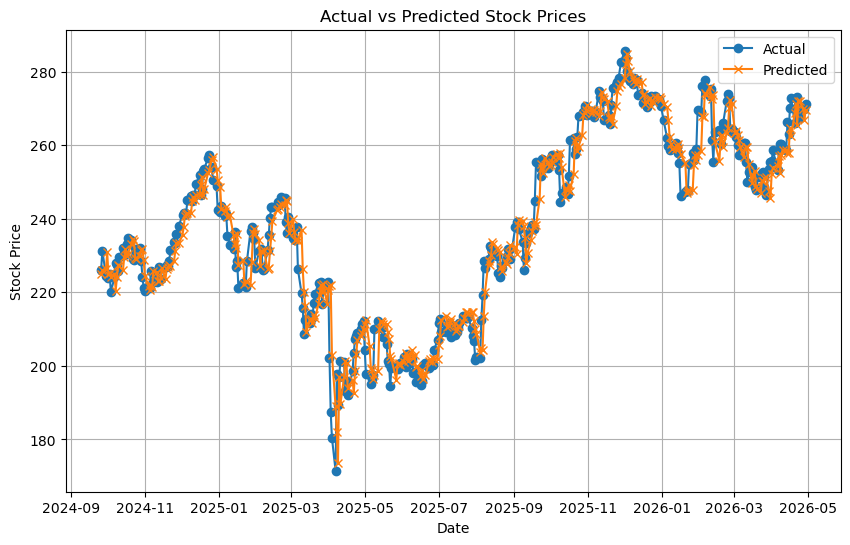

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(Y_test.index, Y_test.values, label='Actual', marker='o')
plt.plot(Y_test.index, y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

In [66]:
print("R² Score:", r2_score(Y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(Y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(Y_test, y_pred)))

R² Score: 0.9461864803086429
Mean Squared Error: 33.05208867918988
Root Mean Squared Error: 5.749094596472551
